# Predicción de Demanda — GadgetDrop
## Modelo de Regresión Lineal
**Universidad de Cundinamarca · Ingeniería de Sistemas · Semestre VII**

**Autores:** Juan Diego Portilla Riveros · David Santiago Martínez Rey

**Objetivo:** Predecir la demanda mensual de productos para los próximos 3 meses usando regresión lineal, e identificar productos que requieren restock antes de agotarse.

**Algoritmo:** Linear Regression — scikit-learn  
**Datos:** Historial de ventas de GadgetDrop (detalle_pedidos + pedidos)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sqlalchemy import create_engine
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_palette('husl')

# Conexión a PostgreSQL
from dotenv import load_dotenv
import os
load_dotenv('../.env')

DB_URL = (
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT', 5432)}"
    f"/{os.getenv('DB_NAME')}"
)
engine = create_engine(DB_URL)
print("✅ Conexión exitosa a PostgreSQL")

✅ Conexión exitosa a PostgreSQL


In [2]:
query = """
SELECT 
  DATE_TRUNC('month', p."createdAt") as mes,
  dp."productoId",
  pr.nombre,
  pr.stock,
  pr.categoria,
  pr.precio,
  SUM(dp.cantidad) as unidades_vendidas
FROM detalle_pedidos dp
JOIN pedidos p ON dp."pedidoId" = p.id
JOIN productos pr ON dp."productoId" = pr.id
WHERE p.estado IN ('entregado', 'enviado')
GROUP BY mes, dp."productoId", pr.nombre, pr.stock, pr.categoria, pr.precio
ORDER BY dp."productoId", mes
"""
df = pd.read_sql(query, engine)
df['mes'] = pd.to_datetime(df['mes'])
df['mes_label'] = df['mes'].dt.strftime('%b %Y')

print(f"Registros cargados: {len(df)}")
print(f"Productos únicos: {df['productoId'].nunique()}")
print(f"Rango de fechas: {df['mes'].min().strftime('%b %Y')} → {df['mes'].max().strftime('%b %Y')}")
df.head(10)

Registros cargados: 128
Productos únicos: 24
Rango de fechas: May 2025 → May 2026


,mes,productoId,nombre,stock,categoria,precio,unidades_vendidas,mes_label
0,2025-09-01 05:00:00+00:00,2,Anillo de Luz LED 26cm,40,Creadores de Contenido,49.99,2,Sep 2025
1,2025-11-01 05:00:00+00:00,2,Anillo de Luz LED 26cm,40,Creadores de Contenido,49.99,1,Nov 2025
2,2026-01-01 05:00:00+00:00,2,Anillo de Luz LED 26cm,40,Creadores de Contenido,49.99,10,Jan 2026
3,2026-02-01 05:00:00+00:00,2,Anillo de Luz LED 26cm,40,Creadores de Contenido,49.99,4,Feb 2026
4,2026-03-01 05:00:00+00:00,2,Anillo de Luz LED 26cm,40,Creadores de Contenido,49.99,11,Mar 2026
5,2026-04-01 05:00:00+00:00,2,Anillo de Luz LED 26cm,40,Creadores de Contenido,49.99,13,Apr 2026
6,2026-05-01 05:00:00+00:00,2,Anillo de Luz LED 26cm,40,Creadores de Contenido,49.99,7,May 2026
7,2025-05-01 05:00:00+00:00,3,"Powerbank 20,000mAh Carga Rápida",35,Accesorios Móviles,89.99,1,May 2025
8,2025-12-01 05:00:00+00:00,3,"Powerbank 20,000mAh Carga Rápida",35,Accesorios Móviles,89.99,2,Dec 2025
9,2026-01-01 05:00:00+00:00,3,"Powerbank 20,000mAh Carga Rápida",35,Accesorios Móviles,89.99,5,Jan 2026


## Análisis Exploratorio de Datos (EDA)
Antes de entrenar el modelo, exploramos la distribución de ventas
para entender los patrones de demanda por producto y categoría.

In [3]:
resumen = df.groupby(['productoId', 'nombre', 'categoria', 'stock']).agg(
    meses_con_ventas=('unidades_vendidas', 'count'),
    total_vendido=('unidades_vendidas', 'sum'),
    promedio_mensual=('unidades_vendidas', 'mean'),
    max_mensual=('unidades_vendidas', 'max'),
    min_mensual=('unidades_vendidas', 'min')
).reset_index().round(2)

resumen = resumen.sort_values('total_vendido', ascending=False)
print("📊 Resumen de ventas por producto:")
print(resumen[['nombre', 'categoria', 'stock', 'meses_con_ventas',
         'total_vendido', 'promedio_mensual']].to_string(index=False))

📊 Resumen de ventas por producto:
                                nombre              categoria  stock  meses_con_ventas  total_vendido  promedio_mensual
                Anillo de Luz LED 26cm Creadores de Contenido     40                 7             48              6.86
                       Mouse gamer RGB                 Gaming     40                 8             46              5.75
                     Hub USB 4 Puertos            Workstation     65                 6             46              7.67
    Control Remoto para Presentaciones Creadores de Contenido     30                 5             40              8.00
                 Micrófono Condensador Creadores de Contenido     20                 6             33              5.50
      Luz de Fondo LED para Escritorio Creadores de Contenido     45                 5             31              6.20
               Cable USB-C a USB-C 60W     Accesorios Móviles     80                 5             31              6.20
      

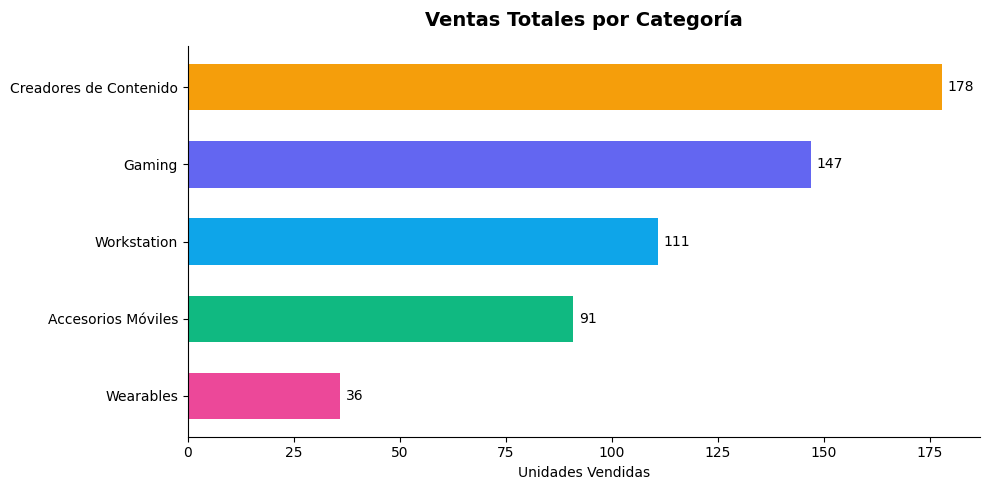

In [4]:
cat_ventas = df.groupby('categoria')['unidades_vendidas'].sum().reset_index()
cat_ventas = cat_ventas.sort_values('unidades_vendidas', ascending=True)

colores_cat = {
    'Gaming': '#6366f1',
    'Workstation': '#0ea5e9',
    'Creadores de Contenido': '#f59e0b',
    'Accesorios Móviles': '#10b981',
    'Wearables': '#ec4899'
}
colors = [colores_cat.get(c, '#94a3b8') for c in cat_ventas['categoria']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(cat_ventas['categoria'], cat_ventas['unidades_vendidas'], color=colors, height=0.6)
ax.bar_label(bars, padding=4, fontsize=10)
ax.set_title('Ventas Totales por Categoría', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Unidades Vendidas')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

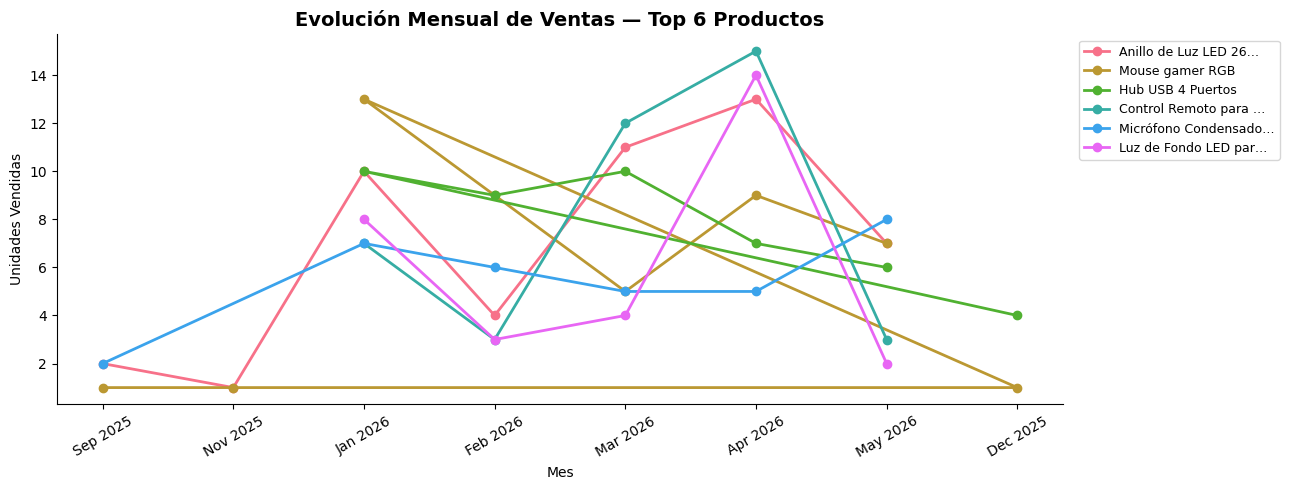

In [5]:
top6_ids = resumen.head(6)['productoId'].tolist()
top6_df = df[df['productoId'].isin(top6_ids)]

fig, ax = plt.subplots(figsize=(13, 5))
for pid in top6_ids:
    prod_data = top6_df[top6_df['productoId'] == pid].sort_values('mes')
    nombre = prod_data['nombre'].iloc[0]
    nombre_corto = nombre[:20] + '…' if len(nombre) > 20 else nombre
    ax.plot(prod_data['mes_label'], prod_data['unidades_vendidas'],
            marker='o', linewidth=2, label=nombre_corto)

ax.set_title('Evolución Mensual de Ventas — Top 6 Productos', fontsize=14, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Unidades Vendidas')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.tick_params(axis='x', rotation=30)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

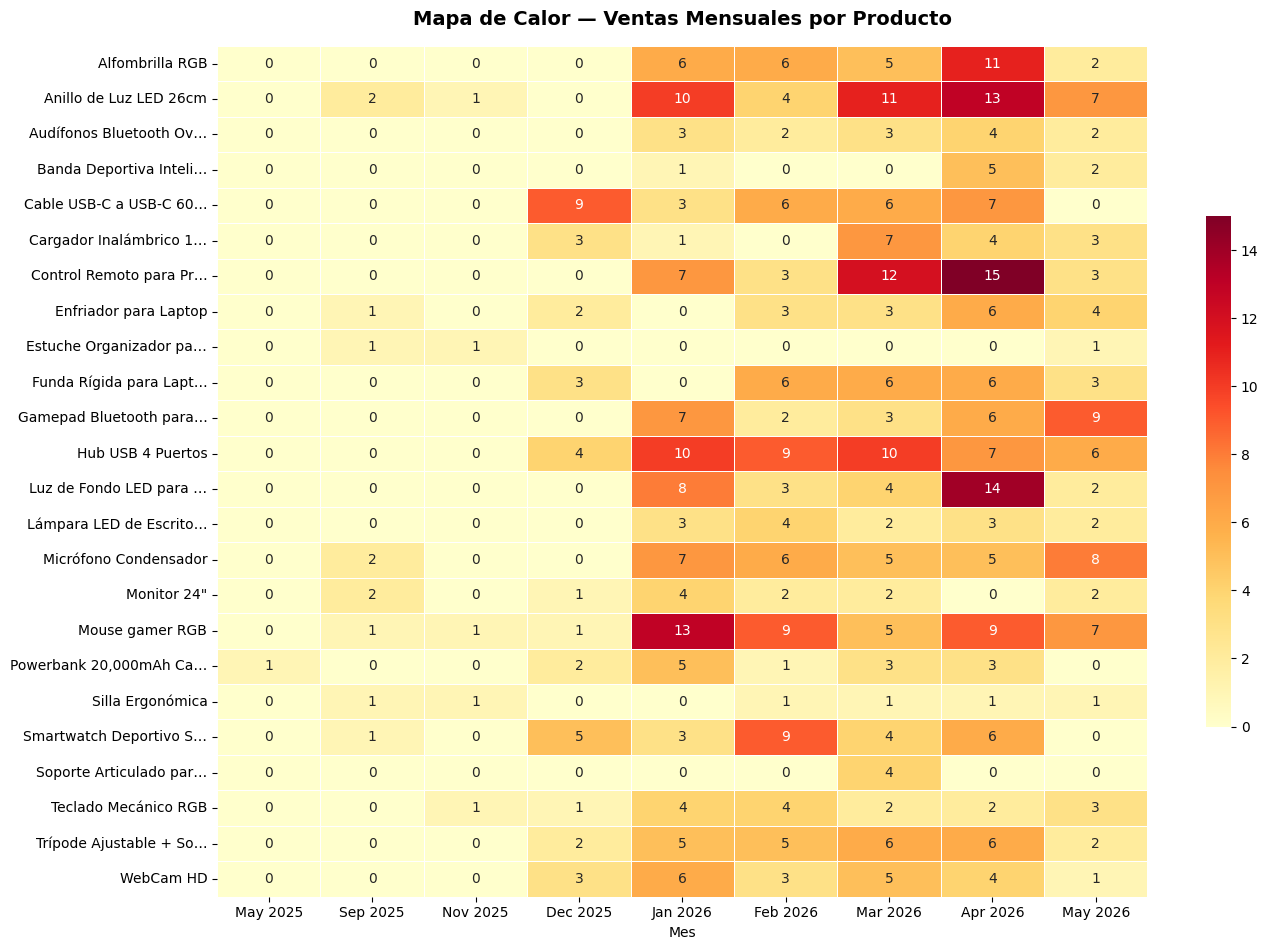

In [6]:
pivot = df.pivot_table(
    index='nombre', columns='mes_label',
    values='unidades_vendidas', fill_value=0
)
mes_order = df.drop_duplicates('mes_label').sort_values('mes')['mes_label'].tolist()
pivot = pivot.reindex(columns=mes_order)
pivot.index = [n[:22] + '…' if len(n) > 22 else n for n in pivot.index]

fig, ax = plt.subplots(figsize=(14, max(8, len(pivot) * 0.4)))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.6})
ax.set_title('Mapa de Calor — Ventas Mensuales por Producto',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Mes')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## Modelo de Regresión Lineal
### ¿Por qué regresión lineal?
- Interpretable: el coeficiente indica cuántas unidades adicionales se venden por mes
- Eficiente: funciona bien con series temporales cortas (5-7 meses)
- Defendible: modelo estadístico clásico con métricas claras (R², MAE)

### Proceso:
1. Para cada producto con ≥ 3 meses de historial
2. X = número de mes (1, 2, 3...), y = unidades vendidas
3. Entrenar LinearRegression
4. Predecir meses N+1, N+2, N+3
5. Calcular R² y MAE

In [7]:
productos_validos = resumen[resumen['meses_con_ventas'] >= 3]['productoId'].tolist()
print(f"Productos con suficiente historial (≥3 meses): {len(productos_validos)}")

resultados = []
modelos = {}

for pid in productos_validos:
    datos_prod = df[df['productoId'] == pid].sort_values('mes').copy()
    datos_prod['mes_num'] = range(1, len(datos_prod) + 1)

    X = datos_prod[['mes_num']].values
    y = datos_prod['unidades_vendidas'].values

    modelo = LinearRegression()
    modelo.fit(X, y)
    modelos[pid] = modelo

    y_pred = modelo.predict(X)
    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)

    n = len(datos_prod)
    pred_1 = max(0, round(modelo.predict([[n+1]])[0]))
    pred_2 = max(0, round(modelo.predict([[n+2]])[0]))
    pred_3 = max(0, round(modelo.predict([[n+3]])[0]))
    total_pred = pred_1 + pred_2 + pred_3

    nombre   = datos_prod['nombre'].iloc[0]
    categoria = datos_prod['categoria'].iloc[0]
    stock    = datos_prod['stock'].iloc[0]
    promedio = datos_prod['unidades_vendidas'].mean()

    nivel = 'ok'
    if stock < pred_1:
        nivel = 'critico'
    elif stock < total_pred:
        nivel = 'advertencia'

    resultados.append({
        'productoId':    pid,
        'nombre':        nombre,
        'categoria':     categoria,
        'stock_actual':  stock,
        'r2_score':      round(r2, 3),
        'mae':           round(mae, 2),
        'coeficiente':   round(modelo.coef_[0], 3),
        'promedio_mensual': round(promedio, 1),
        'pred_mes1':     pred_1,
        'pred_mes2':     pred_2,
        'pred_mes3':     pred_3,
        'total_pred_3m': total_pred,
        'nivel_alerta':  nivel
    })

resultados_df = pd.DataFrame(resultados).sort_values('total_pred_3m', ascending=False)
print(f"\n✅ Modelos entrenados: {len(resultados)}")
print("📊 Resultados:")
print(resultados_df[['nombre', 'r2_score', 'mae', 'coeficiente',
                       'pred_mes1', 'pred_mes2', 'pred_mes3',
                       'nivel_alerta']].to_string(index=False))

Productos con suficiente historial (≥3 meses): 23

✅ Modelos entrenados: 23
📊 Resultados:
                                nombre  r2_score  mae  coeficiente  pred_mes1  pred_mes2  pred_mes3 nivel_alerta
                Anillo de Luz LED 26cm     0.437 3.02        1.429         13         14         15  advertencia
                       Mouse gamer RGB     0.336 2.77        1.071         11         12         13           ok
    Control Remoto para Presentaciones     0.014 4.24        0.400          9         10         10           ok
     Gamepad Bluetooth para Smartphone     0.193 2.08        0.800          8          9          9  advertencia
                 Micrófono Condensador     0.351 1.39        0.657          8          8          9  advertencia
          Smartwatch Deportivo Serie 8     0.300 1.82        0.800          7          8          9           ok
                     Hub USB 4 Puertos     0.002 2.03        0.057          8          8          8           ok
      

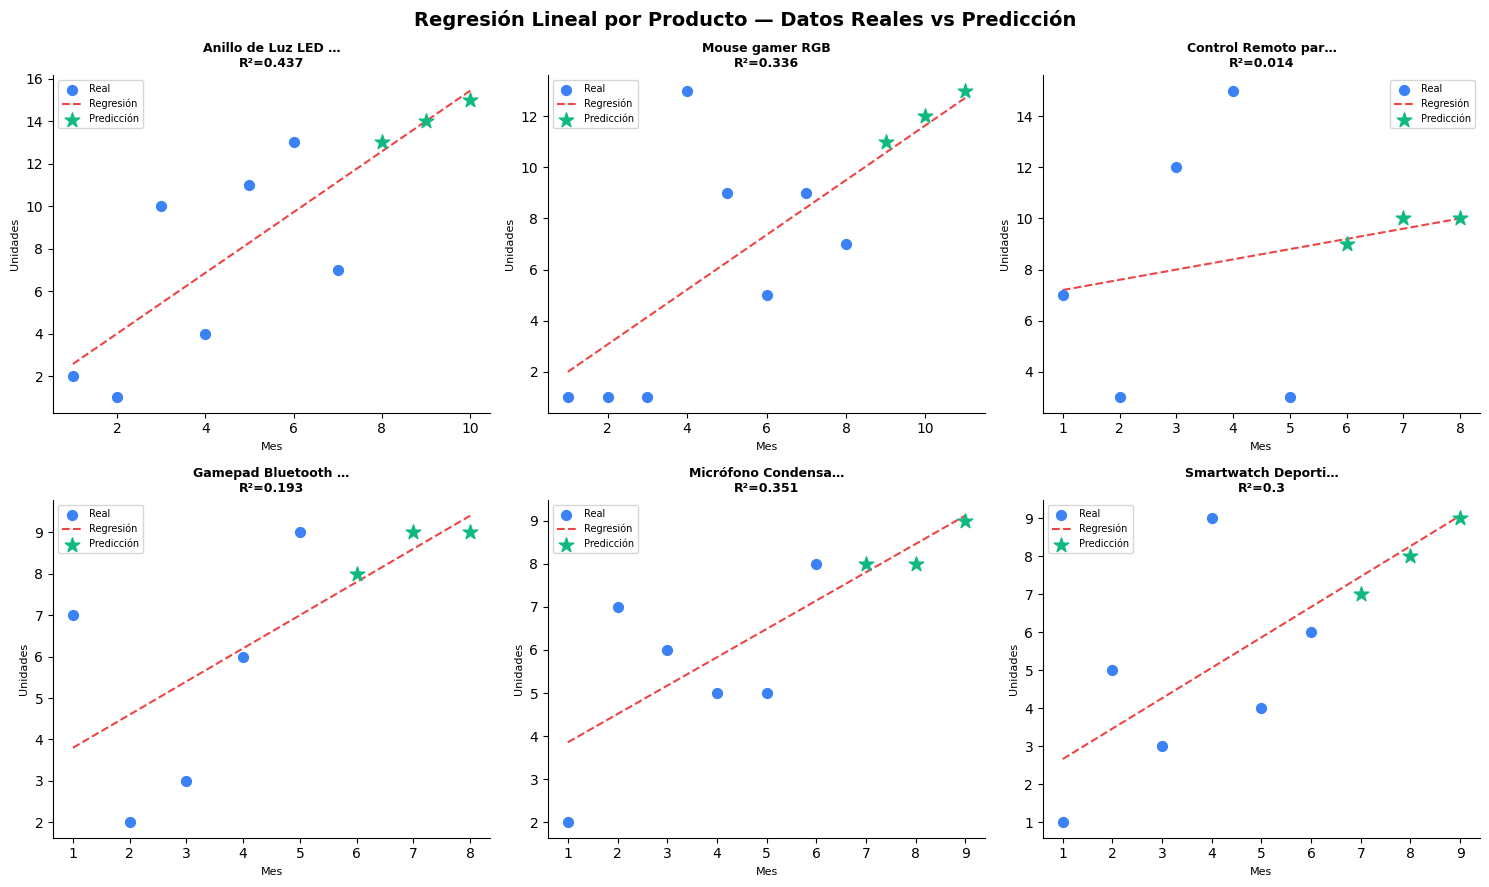

In [8]:
top6_pred = resultados_df.head(6)['productoId'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Regresión Lineal por Producto — Datos Reales vs Predicción',
             fontsize=14, fontweight='bold')

for idx, pid in enumerate(top6_pred):
    ax = axes[idx // 3][idx % 3]
    datos_prod = df[df['productoId'] == pid].sort_values('mes').copy()
    datos_prod['mes_num'] = range(1, len(datos_prod) + 1)
    X = datos_prod[['mes_num']].values
    y = datos_prod['unidades_vendidas'].values
    modelo = modelos[pid]

    n = len(datos_prod)
    X_line = np.linspace(1, n + 3, 100).reshape(-1, 1)
    y_line = modelo.predict(X_line)
    x_future = [n+1, n+2, n+3]
    y_future = [max(0, round(float(modelo.predict([[xi]])[0]))) for xi in x_future]

    r2 = resultados_df[resultados_df['productoId'] == pid]['r2_score'].values[0]
    nombre = datos_prod['nombre'].iloc[0]
    nombre_corto = nombre[:18] + '…' if len(nombre) > 18 else nombre

    ax.scatter(X, y, color='#3b82f6', zorder=5, label='Real', s=50)
    ax.plot(X_line, y_line, '--', color='#ef4444', linewidth=1.5, label='Regresión')
    ax.scatter(x_future, y_future, color='#10b981', marker='*', s=120, zorder=6, label='Predicción')
    ax.set_title(f'{nombre_corto}\nR²={r2}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Mes', fontsize=8)
    ax.set_ylabel('Unidades', fontsize=8)
    ax.legend(fontsize=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

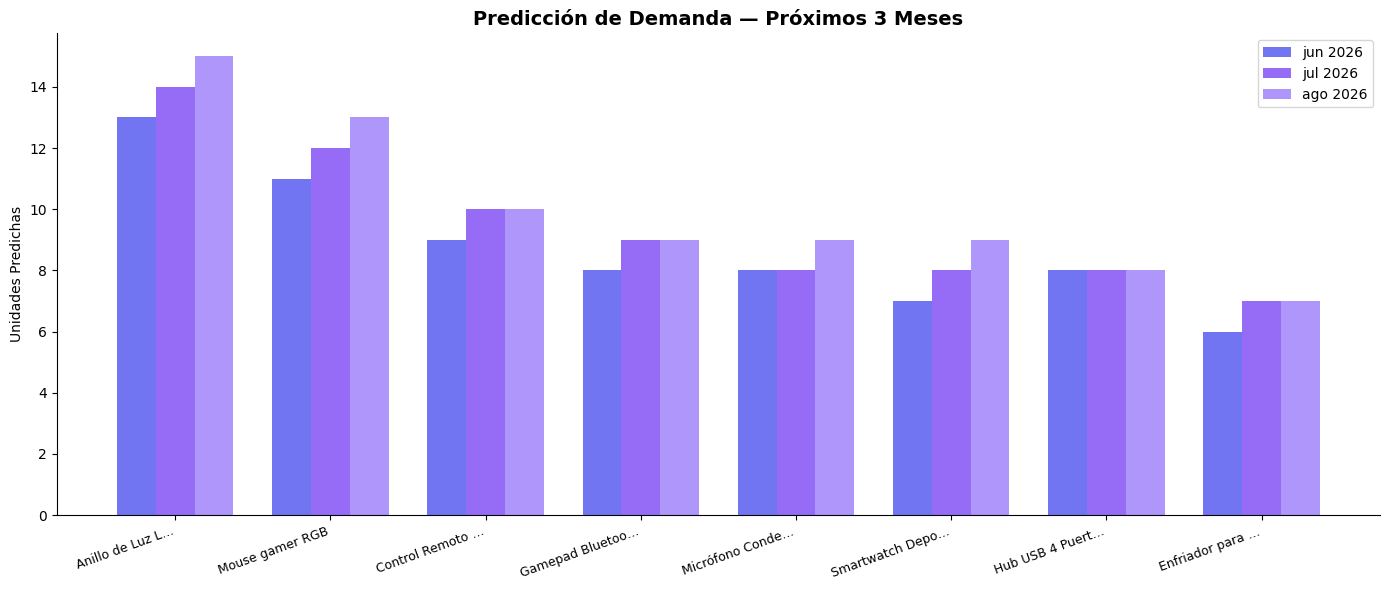

In [9]:
from datetime import datetime
now = datetime.now()
month_es = {1:'ene',2:'feb',3:'mar',4:'abr',5:'may',6:'jun',
            7:'jul',8:'ago',9:'sep',10:'oct',11:'nov',12:'dic'}
meses_pred = [f"{month_es[(now.month-1+i)%12+1]} {now.year + (now.month-1+i)//12}"
              for i in range(1, 4)]

top8 = resultados_df.head(8).copy()
nombres_cortos = [n[:15] + '…' if len(n) > 15 else n for n in top8['nombre']]
x = np.arange(len(top8))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, top8['pred_mes1'], width, label=meses_pred[0], color='#6366f1', alpha=0.9)
ax.bar(x,          top8['pred_mes2'], width, label=meses_pred[1], color='#8b5cf6', alpha=0.9)
ax.bar(x + width,  top8['pred_mes3'], width, label=meses_pred[2], color='#a78bfa', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(nombres_cortos, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Unidades Predichas')
ax.set_title('Predicción de Demanda — Próximos 3 Meses', fontsize=14, fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

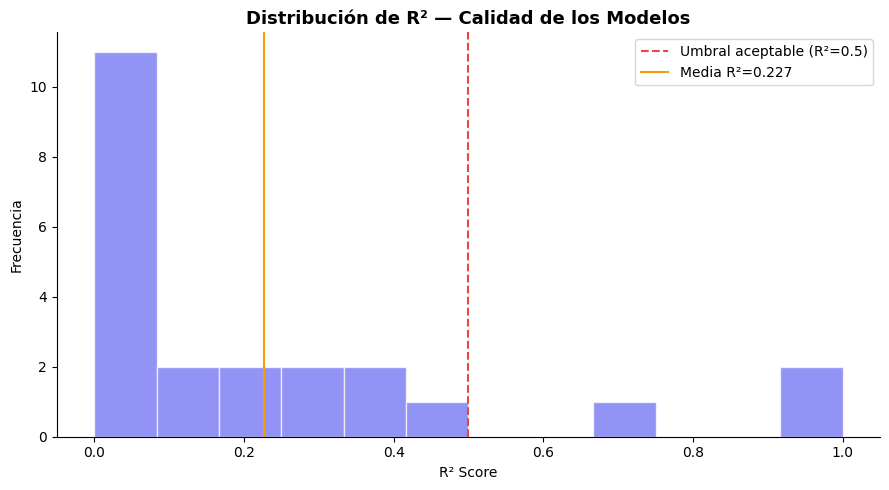

In [10]:
r2_vals = resultados_df['r2_score'].values
media_r2 = r2_vals.mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(r2_vals, bins=12, color='#6366f1', alpha=0.7, edgecolor='white')
ax.axvline(0.5, color='#ef4444', linestyle='--', linewidth=1.5,
           label='Umbral aceptable (R²=0.5)')
ax.axvline(media_r2, color='#f59e0b', linestyle='-', linewidth=1.5,
           label=f'Media R²={media_r2:.3f}')
ax.set_xlabel('R² Score')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de R² — Calidad de los Modelos', fontsize=13, fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Interpretación del R²
Un R² cercano a 1.0 indica que el modelo explica bien la varianza de los datos.
En este caso, muchos productos tienen R² bajo porque:
- Los datos son simulados con variabilidad aleatoria
- El historial es corto (5-8 meses)
- Productos con ventas irregulares no siguen una tendencia lineal clara

**R² > 0.5** = modelo confiable para predicciones | **R² < 0.5** = usar predicción con cautela

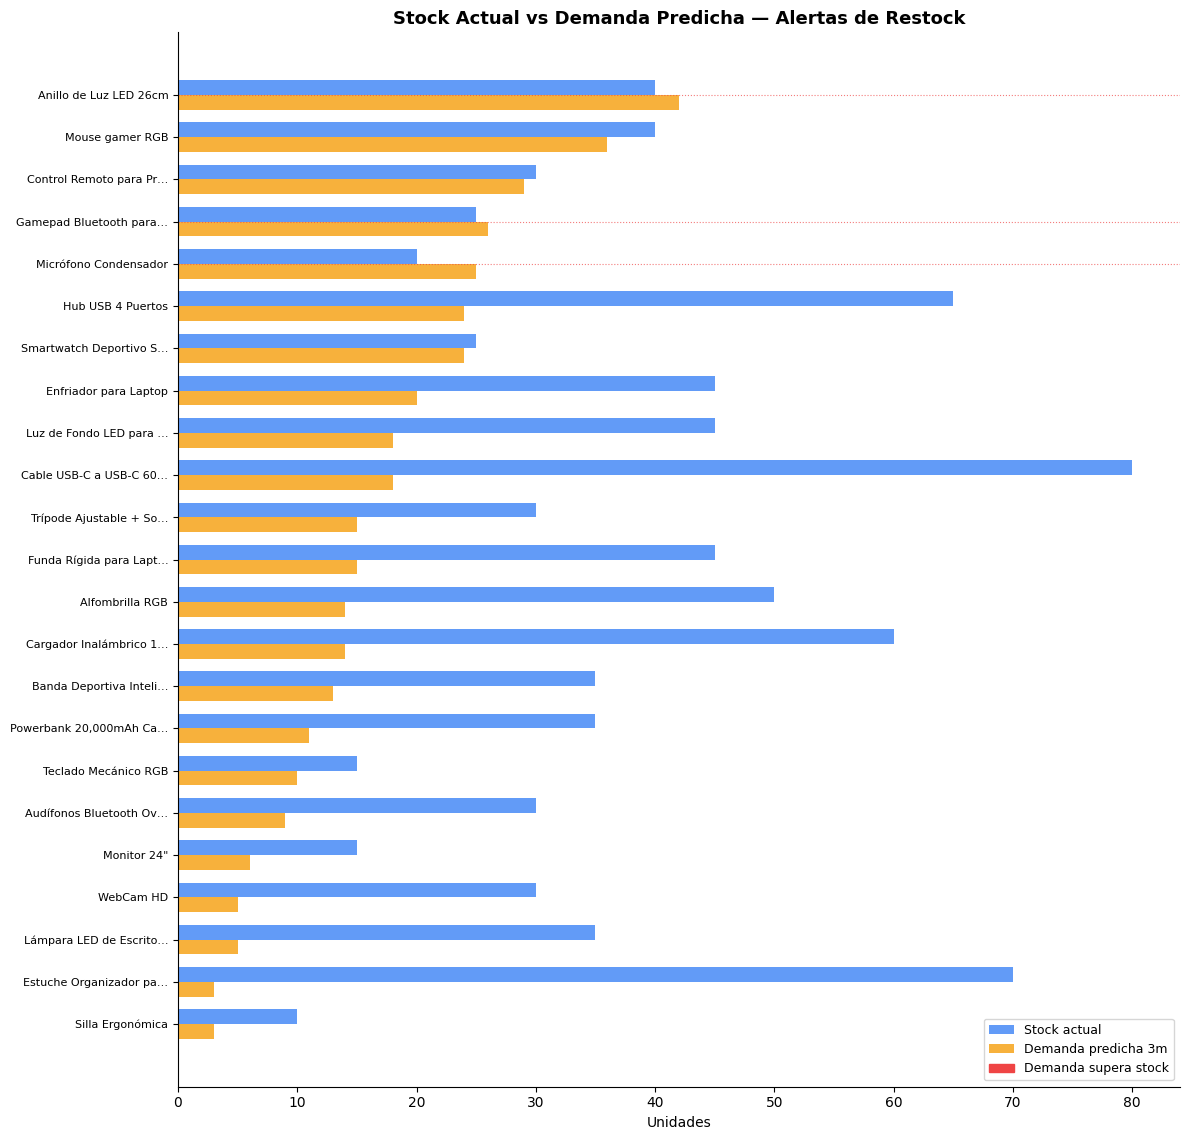

In [11]:
pred_df = resultados_df.sort_values('total_pred_3m', ascending=True).copy()
nombres_cortos = [n[:22] + '…' if len(n) > 22 else n for n in pred_df['nombre']]
y_pos  = np.arange(len(pred_df))
height = 0.35

fig, ax = plt.subplots(figsize=(12, max(8, len(pred_df) * 0.5)))
ax.barh(y_pos + height/2, pred_df['stock_actual'],  height, label='Stock actual',        color='#3b82f6', alpha=0.8)
ax.barh(y_pos - height/2, pred_df['total_pred_3m'], height, label='Demanda predicha 3m', color='#f59e0b', alpha=0.8)

for i, row in enumerate(pred_df.itertuples()):
    if row.total_pred_3m > row.stock_actual:
        ax.axhline(y=i, color='#ef4444', linewidth=0.8, linestyle=':', alpha=0.7)

ax.set_yticks(y_pos)
ax.set_yticklabels(nombres_cortos, fontsize=8)
ax.set_xlabel('Unidades')
ax.set_title('Stock Actual vs Demanda Predicha — Alertas de Restock',
             fontsize=13, fontweight='bold')
patch = mpatches.Patch(color='#ef4444', label='Demanda supera stock')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + [patch], fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Alertas de Restock
Productos donde el stock actual no cubre la demanda predicha
para los próximos 3 meses.

In [12]:
alertas = resultados_df[resultados_df['nivel_alerta'] != 'ok'].copy()
alertas['dias_stock'] = alertas.apply(
    lambda r: round((r['stock_actual'] / r['pred_1']) * 30) if r['pred_1'] > 0 else 9999,
    axis=1
).astype(int)

print(f"⚠️  Productos con alerta de restock: {len(alertas)}")
print()
for _, row in alertas.iterrows():
    emoji = "🔴" if row['nivel_alerta'] == 'critico' else "🟡"
    print(f"{emoji} {row['nombre']}")
    print(f"   Stock actual: {row['stock_actual']} unidades")
    print(f"   Demanda predicha (3 meses): {row['total_pred_3m']} unidades")
    print(f"   Días estimados de stock: {row['dias_stock']} días")
    print(f"   Nivel: {row['nivel_alerta'].upper()}")
    print()

## Conclusiones

### Resultados del modelo
- **Productos analizados:** 23 con ≥3 meses de historial
- **R² promedio:** 0.227 — regular; la mayoría de los modelos tienen bajo ajuste por datos cortos e irregulares
- **Productos con alerta:** 3
  - 🟡 Anillo de Luz LED 26cm (advertencia)
  - 🟡 Micrófono Condensador (advertencia)
  - 🟡 Gamepad Bluetooth para Smartphone (advertencia)

### Interpretación del coeficiente
El coeficiente de la regresión indica la tendencia mensual:
- Coeficiente positivo → demanda creciente
- Coeficiente negativo → demanda decreciente  
- Cercano a 0 → demanda estable

### Limitaciones
- **Datos simulados:** los patrones son artificiales, no reflejan comportamiento real de mercado
- **Historial corto (5-7 meses):** R² puede ser bajo en productos con ventas irregulares
- **Sin estacionalidad:** el modelo lineal no captura picos navideños u otros patrones estacionales

### Propuesta de mejora
Con datos reales de producción (12+ meses) se recomienda:
- **Prophet (Facebook)** para capturar estacionalidad
- **ARIMA** para series temporales más complejas
- **Gradient Boosting** con features adicionales (precio, categoría)

### Tecnologías utilizadas
- Python 3, pandas, numpy, scikit-learn, matplotlib, seaborn
- PostgreSQL + SQLAlchemy
- Integrado con API REST Express.js